This code block handles the initial data loading and preparation. It performs the following steps:

1.  **`import pandas as pd`**: Imports the pandas library, commonly used for data manipulation and analysis, and assigns it the alias `pd` for convenience.
2.  **`import matplotlib.pyplot as plt`**: Imports the `pyplot` module from the matplotlib library, which is used for creating static, animated, and interactive visualizations in Python.
3.  **`from google.colab import files`**: Imports the `files` module from `google.colab`, enabling file uploads directly within the Colab environment.
4.  **`uploaded = files.upload()`**: Prompts the user to upload files. In this case, it expects the `student_clustering.csv` file.
5.  **`df = pd.read_csv("student_clustering.csv")`**: Reads the uploaded CSV file named "student_clustering.csv" into a pandas DataFrame called `df`.
6.  **`X = df.iloc[:,:].values`**: Extracts all rows and columns from the DataFrame `df` and converts them into a NumPy array `X`. This array `X` will be used as the input data for the K-Means clustering algorithm.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("student_clustering.csv")
X = df.iloc[:,:].values

This code block defines a custom implementation of the K-Means clustering algorithm. Here's a breakdown of its components:

*   **`__init__(self, n_clusters=2, max_iter=100)`**: The constructor initializes the K-Means object. It sets the number of clusters (`n_clusters`, default 2) and the maximum number of iterations (`max_iter`, default 100) for the algorithm.

*   **`fit_predict(self, X)`**: This method performs the clustering. It randomly initializes `n_clusters` centroids from the input data `X`. Then, it iteratively assigns data points to the nearest centroid (`assign_clusters`) and updates the centroid positions (`move_centroids`) until the centroids no longer change or the maximum number of iterations is reached. It returns an array indicating the cluster assignment for each data point.

*   **`assign_clusters(self, X)`**: This helper method assigns each data point in `X` to its closest centroid. For each row (data point), it calculates the Euclidean distance to every centroid and assigns the point to the cluster of the nearest centroid.

*   **`move_centroids(self, X, cluster_group)`**: This helper method updates the position of the centroids. For each cluster, it calculates the mean of all data points assigned to that cluster and sets this mean as the new centroid position. This step moves the centroids to the center of their respective clusters.

In [6]:
import random
import numpy as np

class KMeans:
    def __init__(self,n_clusters=2,max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self,X):

        random_index = random.sample(range(0,X.shape[0]),self.n_clusters)
        self.centroids = X[random_index]

        for i in range(self.max_iter):
            # assign clusters
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids
            # move centroids
            self.centroids = self.move_centroids(X,cluster_group)
            # check finish
            if (old_centroids == self.centroids).all():
                break

        return cluster_group

    def assign_clusters(self,X):
        cluster_group = []
        distances = []

        for row in X:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
            min_distance = min(distances)
            index_pos = distances.index(min_distance)
            cluster_group.append(index_pos)
            distances.clear()

        return np.array(cluster_group)

    def move_centroids(self,X,cluster_group):
        new_centroids = []

        cluster_type = np.unique(cluster_group)

        for type in cluster_type:
            new_centroids.append(X[cluster_group == type].mean(axis=0))

        return np.array(new_centroids)


This code block demonstrates the application of the custom K-Means algorithm and visualizes the clustering results. Here's what each line does:

1.  **`km = KMeans(n_clusters=4, max_iter=500)`**: An instance of the `KMeans` class is created. It's configured to find 4 clusters (`n_clusters=4`) and to run for a maximum of 500 iterations (`max_iter=500`).
2.  **`y_means = km.fit_predict(X)`**: The `fit_predict` method of the `km` object is called with the data `X`. This executes the K-Means algorithm, and `y_means` will store an array where each element indicates the cluster ID (0, 1, 2, or 3) to which the corresponding data point in `X` belongs.
3.  **`plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='red')`**
4.  **`plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='blue')`**
5.  **`plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')`**
6.  **`plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color='yellow')`**: These lines generate a scatter plot. For each of the four identified clusters, they plot the data points belonging to that cluster using a different color (`red`, `blue`, `green`, `yellow`). `X[y_means == i, 0]` selects the first feature (x-coordinate) of all points in cluster `i`, and `X[y_means == i, 1]` selects the second feature (y-coordinate).
7.  **`plt.show()`**: Displays the generated scatter plot, showing the clustered data points.

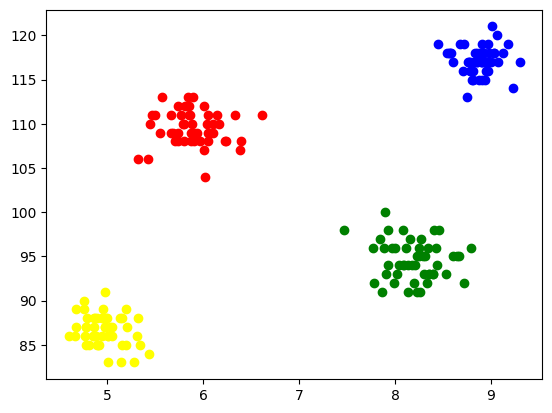

In [7]:
km = KMeans(n_clusters=4,max_iter=500)
y_means = km.fit_predict(X)

plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='red')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='blue')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color='yellow')
plt.show()